In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
import geopandas as gpd

from shapely.geometry import LineString
from shapely.geometry import Point, Polygon as ShapelyPolygon
import matplotlib.pyplot as plt
import seaborn as sns

import cmocean
import cmocean.cm as cmo

import matplotlib.patheffects as path_effects
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import utils

In [2]:
# File Paths to data
repo_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/'
data_path = repo_path + 'data/'
output_path = '/Users/zephyrsylvester/repos/hi-res-AP/circumpolar-connectivity-analysis/'
ibsco_path = data_path + 'IBSCO/'

fig_path = repo_path + 'figures/'
tab_path = fig_path + 'tables/'
map_path = fig_path + 'maps/'


In [3]:
# Path to the downloaded NetCDF file
nc_path = ibsco_path + 'IBCSO_v2_bed_WGS84.nc'

# Open the NetCDF file using xarray
ds = xr.open_dataset(nc_path)

# Crop the bathymetry data to focus on the Antarctic region
bathymetry = ds['z']

In [43]:
# import numpy as np
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature

# # Define grid spacing in degrees
# # 1 degree latitude is approximately 111.32 km
# # Convert 25 km to degrees (this is approximate for longitude)
# grid_spacing_deg = 25 / 111.32

# # Define the extent of the Southern Ocean
# lat_min, lat_max = -90, -50
# lon_min, lon_max = -180, 180

# # Generate grid points
# lons = np.arange(lon_min, lon_max, grid_spacing_deg)
# lats = np.arange(lat_min, lat_max, grid_spacing_deg)
# lon_grid, lat_grid = np.meshgrid(lons, lats)

# # Plotting the grid on a map
# fig = plt.figure(figsize=(12, 12))
# ax = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())

# # Plot the grid points as blue triangles behind the land feature
# ax.scatter(lon_grid, lat_grid, transform=ccrs.PlateCarree(), color='blue', s=0.11, marker='^', zorder=1)

# # Add map features
# ax.add_feature(cfeature.LAND, zorder=2, color='white')
# ax.add_feature(cfeature.OCEAN, zorder=0, color='lightgray')
# ax.coastlines(resolution='110m')

# # Set extent to focus on the Southern Ocean
# ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define grid spacing in degrees
# 1 degree latitude is approximately 111.32 km
# Convert 25 km to degrees (this is approximate for longitude)
grid_spacing_deg = 25 / 111.32

# Define the extent of the Southern Ocean
lat_min, lat_max = -90, -60
lon_min, lon_max = -180, 180
depth_int = np.arange(-1000, 0, 1000)

# Generate grid points
lons = np.arange(lon_min, lon_max, grid_spacing_deg)
lats = np.arange(lat_min, lat_max, grid_spacing_deg)
lon_grid, lat_grid = np.meshgrid(lons, lats)


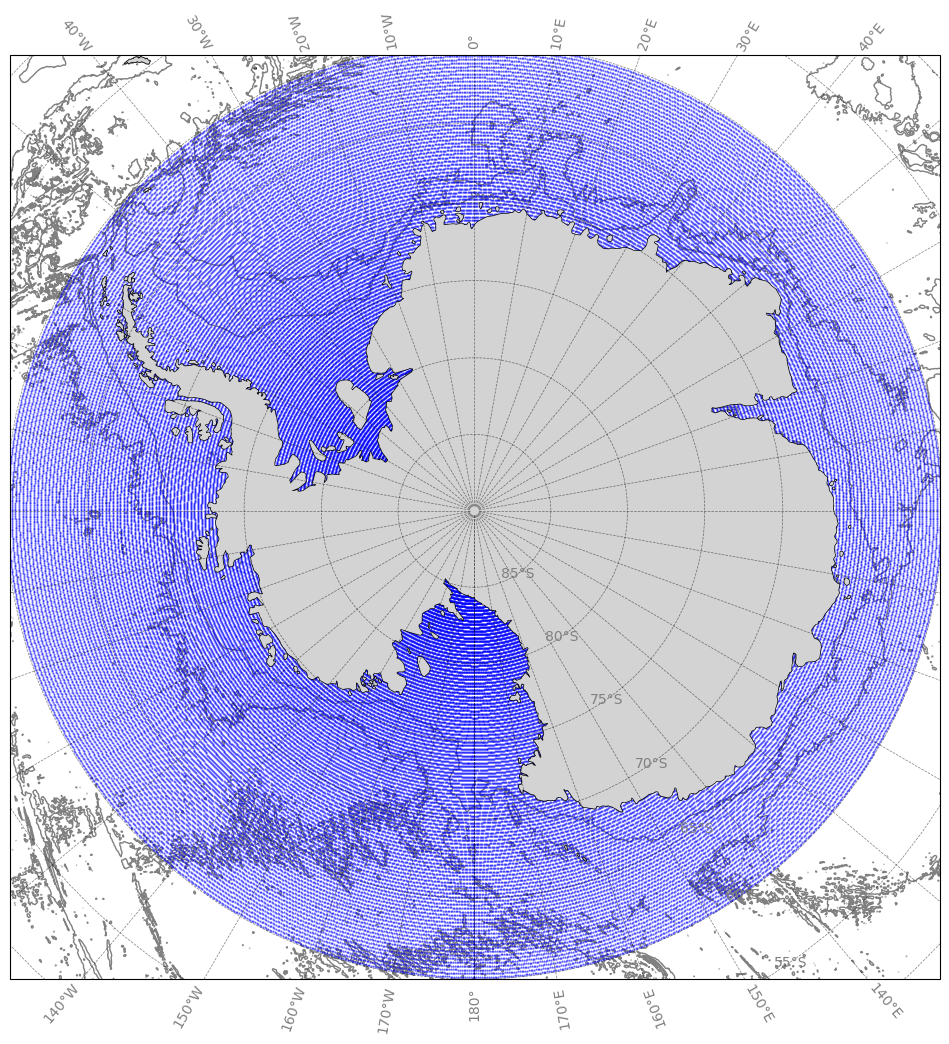

In [5]:

# Plotting the grid on a map
fig = plt.figure(figsize=(12, 12))
ax = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
ax.add_feature(cfeature.COASTLINE, zorder=2)
ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=2)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=1)
gl.xlocator = ticker.FixedLocator(range(-180, 181, 10))
gl.ylocator = ticker.FixedLocator(range(-90, 91, 5))
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Plot the bathymetry contours on the same axis using contour for lines
contour = ax.contour(bathymetry['lon'], bathymetry['lat'], bathymetry,
                     linestyles = 'solid', linewidths=1, colors='grey',
                     transform=ccrs.PlateCarree(), zorder=0)

# Add map features
ax.scatter(lon_grid, lat_grid, transform=ccrs.PlateCarree(), color='blue', s=0.5, alpha=0.5, marker='^', zorder=1)

# Set extent to focus on the Southern Ocean
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
plt.savefig(map_path+'circumpolargrid-s05.png', dpi=200, bbox_inches='tight')

plt.show()# Plot the grid points as blue triangles behind the land feature


In [6]:

# Define grid spacing in degrees
grid_spacing_deg = 25 / 111.32  # Convert 25 km to degrees

# Define the extent of the Southern Ocean
lat_min, lat_max = -90, -50
lon_min, lon_max = -180, 180

# Generate grid points
lons = np.arange(lon_min, lon_max, grid_spacing_deg)
lats = np.arange(lat_min, lat_max, grid_spacing_deg)
lon_grid, lat_grid = np.meshgrid(lons, lats)


In [7]:

# Interpolate bathymetry data onto the grid
bathymetry_interpolated = bathymetry.interp(lon=lon_grid[0, :], lat=lat_grid[:, 0], method='linear')
bathymetry_interpolated

<xarray.DataArray 'z' (lat: 179, lon: 1604)> Size: 2MB
array([[           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,    26.91343968,    25.91343968, ...,
           29.22779047,    28.63643459,            nan],
       [           nan,   355.45018616,   355.45018616, ...,
          352.89299011,   353.89299011,            nan],
       ...,
       [           nan, -4720.56361294, -4580.17157295, ...,
        -4441.63096009, -4423.44230134,            nan],
       [           nan, -4529.96592496, -4513.35681394, ...,
        -4405.50323723, -4416.24757454,            nan],
       [           nan, -4450.76579447, -4483.09343068, ...,
        -3799.4188289 , -3602.86163287,            nan]])
Coordinates:
  * lon      (lon) float64 13kB -180.0 -179.8 -179.6 ... 179.5 179.8 180.0
  * lat      (lat) float64 1kB -90.0 -89.78 -89.55 ... -50.47 -50.25 -50.03
Attributes:
    long_name:     elevation
    grid_mapping:  crs
    units:         m

In [8]:

# Filter grid points by seabed depth (e.g., seabed depth < 3000 meters)
depth_threshold = -3000  # Depth threshold (negative value for seabed)
valid_points = bathymetry_interpolated >= depth_threshold

# Apply the mask to lon and lat grids
filtered_lon = lon_grid[valid_points.values]
filtered_lat = lat_grid[valid_points.values]


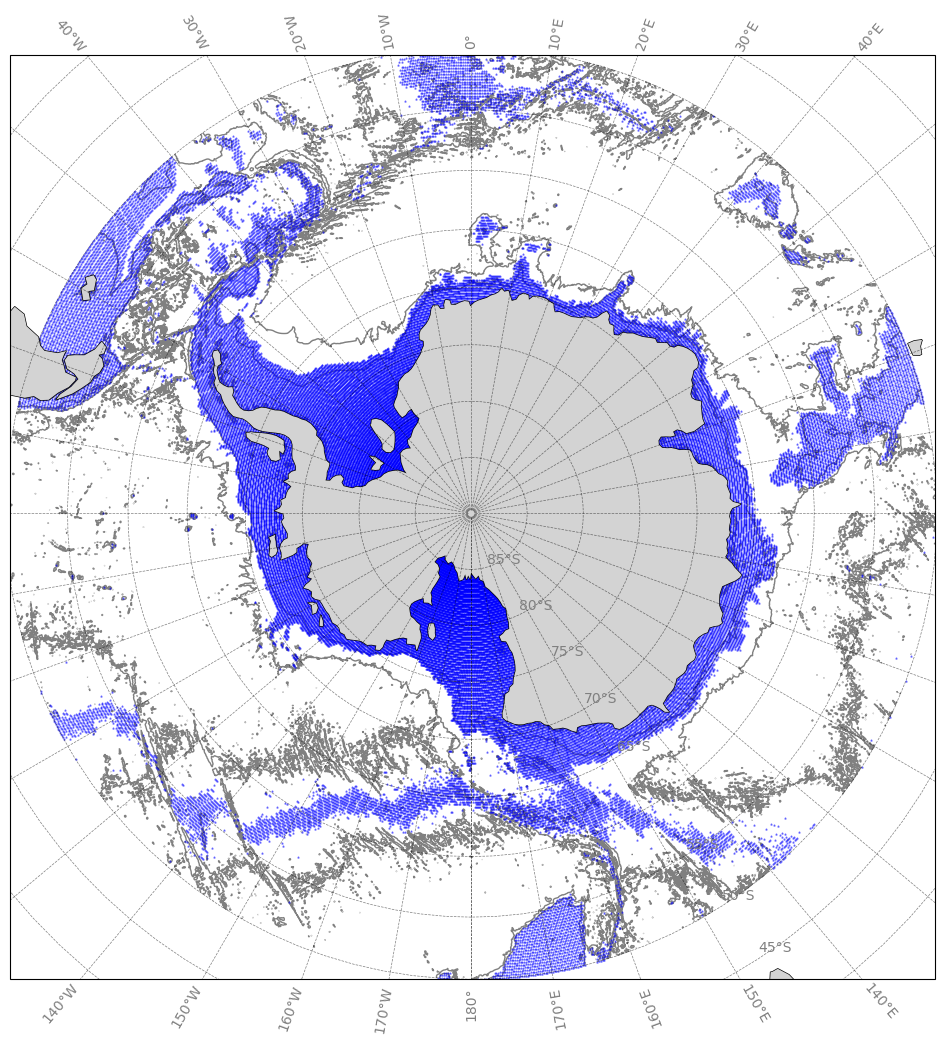

In [63]:
# Plotting the grid on a map
fig = plt.figure(figsize=(12, 12))
ax = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())

# Add map features
ax.add_feature(cfeature.COASTLINE, zorder=2)
ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=2)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=1)
gl.xlocator = ticker.FixedLocator(range(-180, 181, 10))
gl.ylocator = ticker.FixedLocator(range(-90, 91, 5))
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Plot the bathymetry contours on the same axis using contour for lines
contour = ax.contour(bathymetry['lon'], bathymetry['lat'], bathymetry,
                     linestyles='solid', linewidths=1, colors='grey',
                     transform=ccrs.PlateCarree(), zorder=0)

# Plot the filtered grid points as blue triangles behind the land feature
ax.scatter(filtered_lon, filtered_lat, transform=ccrs.PlateCarree(), color='blue', s=0.5, alpha=0.5, marker='^', zorder=1)

# Set extent to focus on the Southern Ocean
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Save the figure
plt.savefig(map_path + 'circumpolargrid-s05.png', dpi=200, bbox_inches='tight')

plt.show()

In [55]:
# Define the cropping range for latitude and longitude
lat_range = slice(-75, -60)

# Crop the dataset by latitude and longitude
bathymetry_antcir = bathymetry.sel(lat=lat_range)


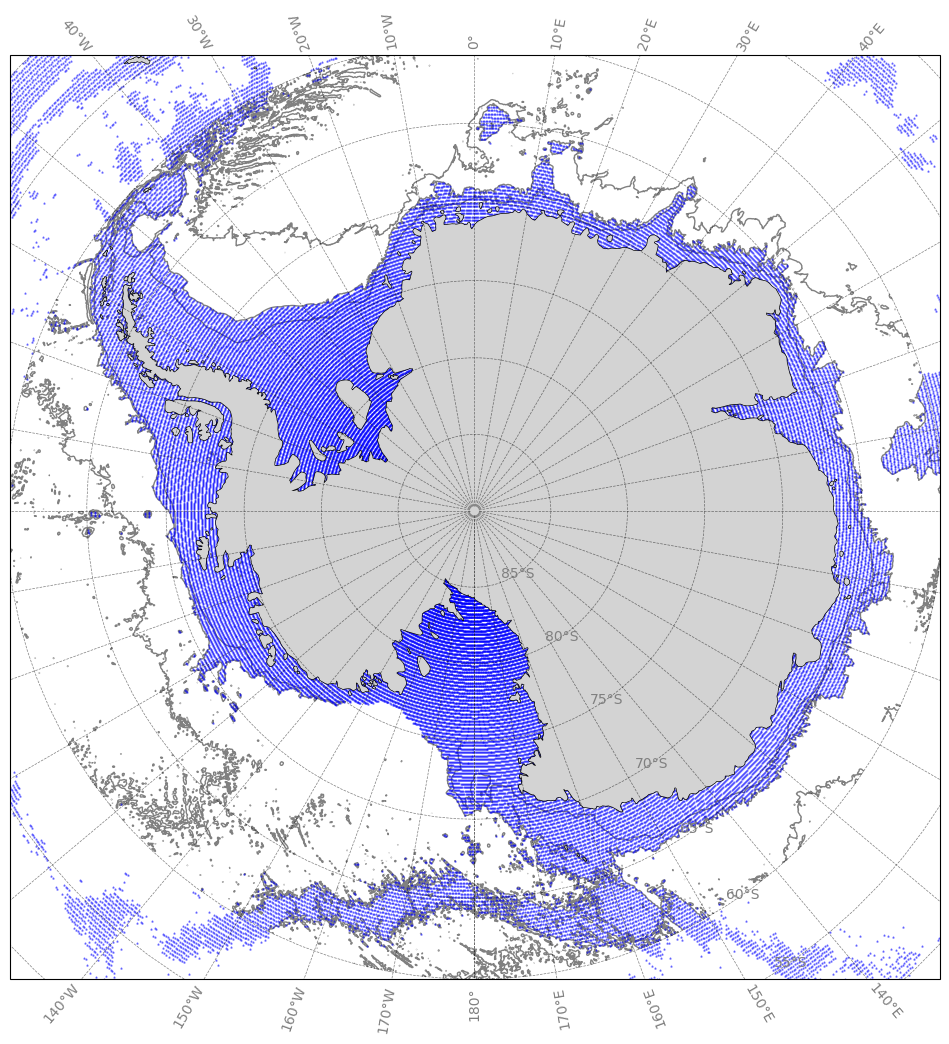

In [59]:
# Plotting the grid on a map
fig = plt.figure(figsize=(12, 12))
ax = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())

# Add map features
ax.add_feature(cfeature.COASTLINE, zorder=2)
ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=2)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=1)
gl.xlocator = ticker.FixedLocator(range(-180, 181, 10))
gl.ylocator = ticker.FixedLocator(range(-90, 91, 5))
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Plot the bathymetry contours on the same axis using contour for lines
contour = ax.contour(bathymetry_antcir['lon'], bathymetry_antcir['lat'], bathymetry_antcir,
                     linestyles='solid', linewidths=1, colors='grey',
                     transform=ccrs.PlateCarree(), zorder=0)

# Plot the filtered grid points as blue triangles behind the land feature
ax.scatter(filtered_lon, filtered_lat, transform=ccrs.PlateCarree(), color='blue', s=0.5, alpha=0.5, marker='^', zorder=1)

# Set extent to focus on the Southern Ocean
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Save the figure
plt.savefig(map_path + 'circumpolargrid-s05-crop.png', dpi=200, bbox_inches='tight')

plt.show()